In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import metrics
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from collections import Counter
from sklearn.metrics import classification_report


from torch.utils.data import Dataset
from sklearn.preprocessing import StandardScaler
from torch.utils.data import random_split, DataLoader, Subset
import statistics as st
import os
from torch.utils.data import ConcatDataset
from scipy import stats
RANDOM_SEED = 42

print("Done")


Done


In [13]:
#model block
import torch
import torch.nn as nn
import torch.nn.functional as F


class Conv2DBlock(nn.Module):
    def __init__(self, output_size):
        super(Conv2DBlock, self).__init__()
        self.conv_block = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),  # Output: 16x4x4
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
             # Output: 32x2x2
        )
        self.fc = nn.Linear(128, output_size)

    def forward(self, x):
        x = self.conv_block(x)
        x = x.view(x.size(0), -1)  # Flatten, (batch_size, 16*4*4)
        x = self.fc(x)             # (batch_size, output_size)
        return x



class Model(nn.Module):
    def __init__(self, num_classes):
        super(Model, self).__init__()
        self.fl1d = nn.Linear(12, 32)  # 2 IMU streams × 6 features = 12
        self.lstm = nn.LSTM(input_size=32, hidden_size=64, num_layers=2, batch_first=True)
        self.fc = nn.Linear(64, num_classes)

        # Learnable weights for each IMU stream
        self.hand_weight = nn.Parameter(torch.ones(1))
        self.head_weight = nn.Parameter(torch.ones(1))

    def forward(self, sh1, sh2):
        # sh1, sh2: (batch, timesteps, 6)
        sd_hand = self.hand_weight * sh1
        sd_head = self.head_weight * sh2
        sd = torch.cat((sd_hand, sd_head), dim=2)  # (batch, timesteps, 12)
        sd = self.fl1d(sd)  # (batch, timesteps, 32)

        lstm_out, _ = self.lstm(sd)
        final_output = lstm_out[:, -1, :]
        logits = self.fc(final_output)
        output = F.softmax(logits, dim=1)
        return output


In [14]:
#Dataloader ---->change for every movement model



# class CustomLoader(Dataset):
#     def __init__(self, data_path, activity_column, timesteps,weights):
#         self.data = pd.read_csv(data_path, header=0)  # Load CSV data
#         self.activity_column = activity_column  # Column name or index for activity
#         self.timesteps = timesteps  # Length of time steps
#         self.weights = weights

#         # Fit StandardScaler on relevant columns
#         columns_to_scale = self.data.columns[2:7].tolist() + self.data.columns[160:166].tolist()
#         self.scaler = StandardScaler()
#         self.data[columns_to_scale] = self.scaler.fit_transform(self.data[columns_to_scale])

#         # Precompute total samples
#         self.total_samples = len(self.data) - self.timesteps + 1

#     def __len__(self):
#         return self.total_samples

#     def __getitem__(self, idx):
#         if idx < 0 or idx >= self.total_samples:
#             raise IndexError(f'Index {idx} out of range')


#         acc_gcc_columns_hand = [4, 5, 6,1, 2, 3]
#         acc_gcc_columns_head = [163, 164, 165,160, 161, 162]
#         ambient_sensor_columns = [85, 155, 156]

#         # Extract sensor data
#         # Get the number of rows in the data
#         num_rows = len(self.data)

# # Ensure the index does not exceed the bounds
#         if idx + self.timesteps <= num_rows:
#             sensor_head = self.data.iloc[idx:idx + self.timesteps, acc_gcc_columns_head].values
#             sensor_hand = self.data.iloc[idx:idx + self.timesteps, acc_gcc_columns_hand].values






#                 # Extract ambient data
#             ambient_data = self.data.iloc[idx:idx + self.timesteps, ambient_sensor_columns].values


#             # Extract image data
#             imagef = self.data.iloc[idx:idx + self.timesteps, 16:80].values
#             images = self.data.iloc[idx:idx + self.timesteps, 86:150].values

#         # Reshape images to (timesteps, 1, 8, 8)
#         image1 = imagef.reshape(-1, 1,8, 8)
#         image2 = images.reshape(-1,1,8, 8)

#         # Extract labels
#         labels = (self.data.iloc[idx:idx + self.timesteps, self.activity_column].values)
#         labels = stats.mode(labels)[0]







#         # Convert all to torch tensors
#         sensor_head = torch.tensor(sensor_head, dtype=torch.float32)
#         #sensor_head = sensor_head.permute(0, 2, 1)

#         sensor_hand = torch.tensor(sensor_hand, dtype=torch.float32)
#         #sensor_hand = sensor_hand.permute(0, 2, 1)
#         ambient_data = torch.tensor(ambient_data, dtype=torch.float32)
#         image1 = torch.tensor(image1, dtype=torch.float32)
#         image2 = torch.tensor(image2, dtype=torch.float32)
#         labels = torch.tensor(labels, dtype=torch.long)

#         return self.weights[0]*sensor_hand, self.weights[1]*sensor_head, self.weights[2]*ambient_data, self.weights[3]*image1, self.weights[4]*image2, labels


import torch
from torch.utils.data import Dataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
from scipy import stats

class CustomLoader(Dataset):
    def __init__(self, data_path, activity_column, timesteps, weights):
        self.data = pd.read_csv(data_path, header=0)
        self.activity_column = activity_column
        self.timesteps = timesteps
        self.weights = weights

        # Columns for two IMU streams 
        imu1_columns = [4, 5, 6,1,2,3]   
        imu2_columns = [7,8,9,10,11,12] 

        # Scale only the IMU columns
        columns_to_scale = [self.data.columns[i] for i in imu1_columns + imu2_columns]
        self.scaler = StandardScaler()
        self.data[columns_to_scale] = self.scaler.fit_transform(self.data[columns_to_scale])

        self.imu1_columns = imu1_columns
        self.imu2_columns = imu2_columns
        self.total_samples = len(self.data) - self.timesteps + 1

    def __len__(self):
        return self.total_samples

    def __getitem__(self, idx):
        if idx < 0 or idx >= self.total_samples:
            raise IndexError(f'Index {idx} out of range')

        # Extract IMU data for the given window
        imu1 = self.data.iloc[idx:idx + self.timesteps, self.imu1_columns].values
        imu2 = self.data.iloc[idx:idx + self.timesteps, self.imu2_columns].values

        # Extract label (mode of the window)
        labels = self.data.iloc[idx:idx + self.timesteps, self.activity_column].values
        label = stats.mode(labels, keepdims=True)[0][0]

        # Convert to torch tensors
        imu1 = torch.tensor(imu1, dtype=torch.float32)
        imu2 = torch.tensor(imu2, dtype=torch.float32)
        label = torch.tensor(label, dtype=torch.long)

        return self.weights[0] * imu1, self.weights[1] * imu2, label



In [15]:

data_path = "C:/Users/mohit/Desktop/Meeting Acitvity Recognition/Data"
activity_column = 13 #fingers
timesteps = 20 #window size
batch_size = 32
weights = [1,1,1,1,1]

datal=[]

for folder in os.listdir(data_path):
    pth = os.path.join(data_path,folder)

    for file in os.listdir(pth):

        path = os.path.join(pth, file)
        print(file)


        d = CustomLoader(data_path=path, activity_column=activity_column, timesteps=timesteps, weights=weights)





        datal.append(d)




dataset = ConcatDataset(datal)


train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size

# Split the dataset
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

# DataLoaders for train and test sets
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)


# for batch in train_loader:
#     sensor_head,sensor_hand, ambient_data, image1, image2, labels = batch
#     print(sensor_head.shape)

#     print(sensor_hand.shape)
#     print(ambient_data.shape)
#     datac = torch.cat((sensor_hand, sensor_head, ambient_data), dim=2)
#     print(image1.shape)
#     print(image2.shape)
#     print(labels.shape)

#     model = Model(5)

#     print("Con2D ",model(image1,image2,sensor_hand,sensor_head,ambient_data).shape)

#     break
# #




device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



AnushkaSittingDCwBuffer.csv
AnushkaSittingDWwBuffer.csv
AnushkaSittingScrollingwBuffer.csv
AnushkaSittingTalkingwBuffer.csv
AnushkaSittingTypingwBuffer.csv
AnushkaSittingWritingwBuffer.csv
AnushkaStandingDCwBuffer.csv
AnushkaStandingErasingwBuffer.csv
AnushkaStandingTalkingwBuffer.csv
AnushkaStandingWBwBuffer.csv
MohitSittingDrinkingWaterwBuffer.csv
MohitSittingScrollingwBuffer.csv
MohitSittingTalkingwBuffer.csv
MohitSittingTypingwBuffer.csv
MohitSittingWritingwBuffer.csv
MohitStandingDrinkingWaterwBuffer.csv
MohitStandingErasingwBuffer.csv
MohitStandingTalkingwBuffer.csv
MohitStandingWritingwBuffer.csv
SaiScrollingOnPhonewBuffer.csv
SaiSittingDWwBuffer.csv
SaiSittingTalkingwBuffer.csv
SaiSittingTypingwBuffer.csv
SaiSittingWritingwBuffer.csv
SaiStandingDWwoBuffer.csv
SaiStandingErasingwoBuffer.csv
SaiStandingTalkingwoBuffer.csv
SaiStandingWBwoBuffer.csv
arnabsittingDWwBuffer.csv
arnabsittingscrollingwBuffer.csv
arnabsittingtalkingwBuffer.csv
arnabstandingtalkingwBuffer.csv
arnabstandin

In [16]:
from collections import Counter
import torch
import torch.nn as nn

# Step 1: Check class balance
all_labels = []

# Collect all labels from the dataset
# for data in train_loader:  # Adjust the loop for your dataset
#     _, _, _, _, _, labels = data  # Adjust to your data structure
#     all_labels.extend(labels.cpu().numpy().tolist())  # Convert to a list of labels
for data in train_loader:
    _, _, labels = data  # Only two IMUs and labels
    all_labels.extend(labels.cpu().numpy().tolist())

# No need to flatten since `all_labels` contains individual integer labels
# all_labels = [item for sublist in all_labels for item in sublist]  # <-- Remove this line

# Count the occurrence of each class label
class_counts = Counter(all_labels)
print("Class counts:", class_counts)

# Convert to a list of class counts if you know the number of classes
num_classes = 12  # Adjust this based on your number of classes
class_counts_list = [class_counts.get(i, 0) for i in range(num_classes)]  # Safeguard for missing classes
print(f"Class counts: {class_counts_list}")



# Step 2: Calculate class weights (inverse of class frequency)
class_weights = [1.0 / count if count > 0 else 0 for count in class_counts_list]  # Avoid division by zero
print("Class weights:", class_weights)

# Convert class weights to tensor
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

# Step 3: Assign class weights to CrossEntropyLoss
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor).to(device)

# Use the criterion in your training loop as usual





Class counts: Counter({11: 3141, 2: 2674, 5: 2553, 3: 2459, 7: 2230, 1: 2186, 9: 2017, 4: 1822, 0: 1645, 8: 1366, 10: 1236})
Class counts: [1645, 2186, 2674, 2459, 1822, 2553, 0, 2230, 1366, 2017, 1236, 3141]
Class weights: [0.0006079027355623101, 0.0004574565416285453, 0.00037397157816005983, 0.00040666937779585197, 0.0005488474204171241, 0.0003916960438699569, 0, 0.0004484304932735426, 0.0007320644216691069, 0.0004957858205255329, 0.0008090614886731392, 0.0003183699458771092]


Epoch [1/20], Batch [10/365], Loss: 2.4846
Epoch [1/20], Batch [20/365], Loss: 2.4844
Epoch [1/20], Batch [30/365], Loss: 2.4847
Epoch [1/20], Batch [40/365], Loss: 2.4843
Epoch [1/20], Batch [50/365], Loss: 2.4841
Epoch [1/20], Batch [60/365], Loss: 2.4836
Epoch [1/20], Batch [70/365], Loss: 2.4840
Epoch [1/20], Batch [80/365], Loss: 2.4835
Epoch [1/20], Batch [90/365], Loss: 2.4833
Epoch [1/20], Batch [100/365], Loss: 2.4832
Epoch [1/20], Batch [110/365], Loss: 2.4835
Epoch [1/20], Batch [120/365], Loss: 2.4832
Epoch [1/20], Batch [130/365], Loss: 2.4824
Epoch [1/20], Batch [140/365], Loss: 2.4834
Epoch [1/20], Batch [150/365], Loss: 2.4826
Epoch [1/20], Batch [160/365], Loss: 2.4824
Epoch [1/20], Batch [170/365], Loss: 2.4823
Epoch [1/20], Batch [180/365], Loss: 2.4817
Epoch [1/20], Batch [190/365], Loss: 2.4811
Epoch [1/20], Batch [200/365], Loss: 2.4814
Epoch [1/20], Batch [210/365], Loss: 2.4817
Epoch [1/20], Batch [220/365], Loss: 2.4796
Epoch [1/20], Batch [230/365], Loss: 2.47

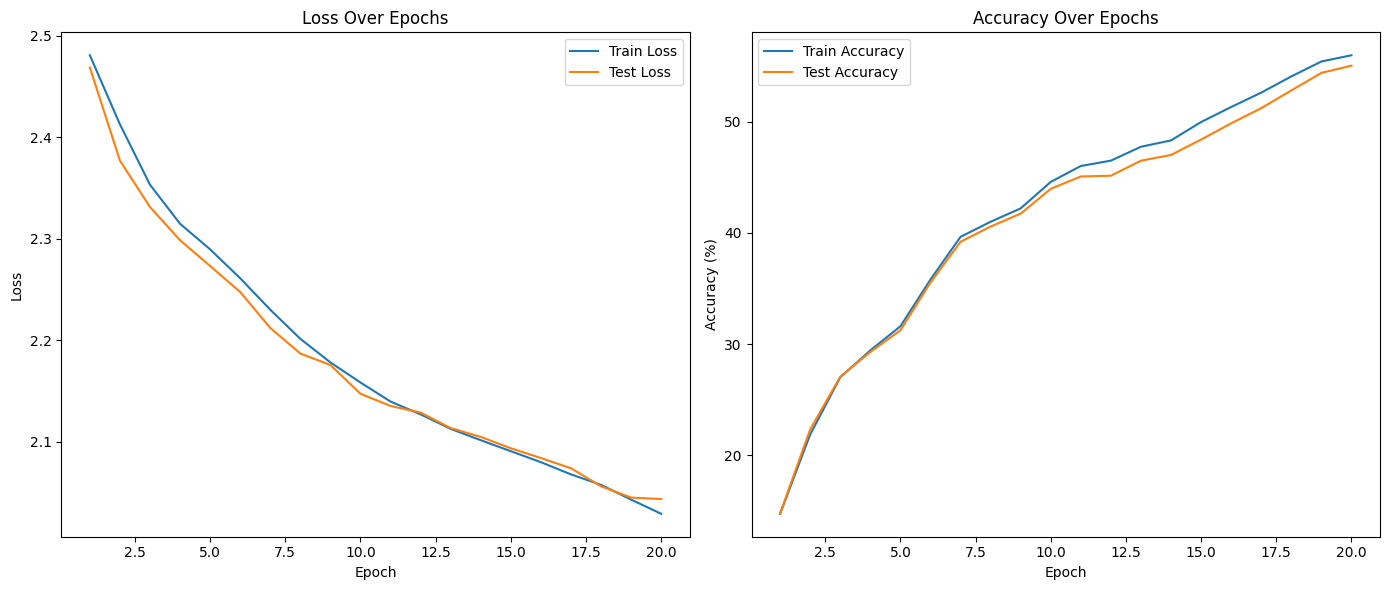

C:\Users\mohit\AppData\Local\Temp\ipykernel_10300\646962947.py:173: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  test_model.load_state_dict(torch.load('model_fingers_40.pth

Precision for each class: [0.34673913 0.56092437 0.59292035 0.63850932 0.39138577 0.56451613
 0.70175439 0.68708972 0.60935351 0.60042283 0.61800819]
Recall for each class: [0.80352645 0.93356643 0.10014948 0.85524126 0.43907563 0.05279035
 0.07207207 0.92899408 0.90778689 0.92810458 0.58984375]
F1 score for each class: [0.48443432 0.7007874  0.1713555  0.7311522  0.41386139 0.09655172
 0.13071895 0.78993711 0.72921811 0.72913992 0.6035976 ]

Weighted Precision: 0.5789336538021006
Weighted Recall: 0.5506600377164409
Weighted F1 score: 0.4783692624696921

Micro Precision: 0.5506600377164409
Micro Recall: 0.5506600377164409
Micro F1 score: 0.5506600377164409


In [17]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

# Check if CUDA is available and set the device


# Move the model to the CUDA device
model = Model(num_classes=12).to(device)

optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Training loop variables
num_epochs = 20
train_losses = []
test_losses = []
train_accuracies = []
test_accuracies = []


# def calculate_accuracy(loader, model):
#     correct = 0
#     total = 0
#     model.eval()  # Set model to evaluation mode
#     with torch.no_grad():  # Disable gradient computation
#         for batch in loader:
#             s1, s2, ad, image1, image2, labels = [tensor.to(device) for tensor in batch]  # Move batch tensors to device

#             output = model(image1, image2, s1, s2, ad).float()  # Forward pass
#             _, predicted = torch.max(output, 1)  # Get predicted class indices
#             total += labels.size(0)  # Total number of labels

#             # Ensure labels and predicted have the same data type and size
#             predicted = predicted.view(-1)
#             labels = labels.view(-1).long()

#             correct += (predicted == labels).sum().item()  # Count correct predictions

#     accuracy = 100 * correct / total  # Calculate accuracy as a percentage
#     return accuracy
def calculate_accuracy(loader, model):
    correct = 0
    total = 0
    model.eval()
    with torch.no_grad():
        for batch in loader:
            s1, s2, labels = [tensor.to(device) for tensor in batch]
            output = model(s1, s2).float()
            _, predicted = torch.max(output, 1)
            total += labels.size(0)
            predicted = predicted.view(-1)
            labels = labels.view(-1).long()
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return accuracy

# Training loop
for epoch in range(num_epochs):
    model.train()  # Set the model to training mode
    running_loss = 0.0
    total_train_loss = 0.0

    for i, batch in enumerate(train_loader):
        s1, s2, labels = [tensor.to(device) for tensor in batch]
        output = model(s1, s2).float()
        labels = labels.squeeze()
        loss = criterion(output, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


    # for i, batch in enumerate(train_loader):
    #     s1, s2, ad, image1, image2, labels = [tensor.to(device) for tensor in batch]  # Move batch tensors to device

    #     # Forward pass
    #     output = model(image1, image2, s1, s2, ad).float()

    #     # Ensure labels are in 1D shape
    #     labels = labels.squeeze()

    #     # Calculate the loss
    #     loss = criterion(output, labels)

    #     # Backward pass and optimization
    #     optimizer.zero_grad()
    #     loss.backward()
    #     optimizer.step()

        running_loss += loss.item()
        total_train_loss += loss.item()

        if i % 10 == 9:  # Print every 10 mini-batches
            print(f'Epoch [{epoch + 1}/{num_epochs}], Batch [{i + 1}/{len(train_loader)}], Loss: {running_loss / 10:.4f}')
            running_loss = 0.0

    # Record average train loss for the epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Calculate train and test accuracy after each epoch
    train_accuracy = calculate_accuracy(train_loader, model)
    test_accuracy = calculate_accuracy(test_loader, model)

    train_accuracies.append(train_accuracy)
    test_accuracies.append(test_accuracy)

    print(f'Epoch [{epoch + 1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {train_accuracy:.2f}%, Test Accuracy: {test_accuracy:.2f}%')

    # Evaluate on test set
    model.eval()
    total_test_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            # s1, s2, ad, image1, image2, labels = [tensor.to(device) for tensor in batch]  # Move batch tensors to device
            # output = model(image1, image2, s1, s2, ad).float()
            s1, s2,labels = [tensor.to(device) for tensor in batch]  # Move batch tensors to device
            output = model( s1, s2).float()
            # Ensure labels are in 1D shape
            labels = labels.squeeze()

            loss = criterion(output, labels)
            total_test_loss += loss.item()

    avg_test_loss = total_test_loss / len(test_loader)
    test_losses.append(avg_test_loss)

    # Save the model after each epoch
    torch.save(model.state_dict(), 'model_fingers_40.pth')

print("Training completed.")

# Plotting loss and accuracy
epochs_range = range(1, num_epochs + 1)

plt.figure(figsize=(14, 6))

# Plot training and test loss
plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Train Loss')
plt.plot(epochs_range, test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Over Epochs')
plt.legend()

# Plot training and test accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Train Accuracy')
plt.plot(epochs_range, test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Accuracy Over Epochs')
plt.legend()

plt.tight_layout()
plt.savefig("train_test.pdf")
plt.show()


# In[7]:


import torch
from sklearn.metrics import precision_score, recall_score, f1_score

# model load
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

test_model = Model(num_classes=12).to(device)
test_model.load_state_dict(torch.load('model_fingers_40.pth'))


# def test_metrics(model, loader):
#     device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # Check if GPU is available
#     model.to(device)  # Move model to the appropriate device

#     y_pred = []
#     y_true = []

#     model.eval()  # Set model to evaluation mode
#     with torch.no_grad():  # Disable gradient computation
#         for batch in loader:
#             s1, s2, ad, image1, image2, labels = batch

#             # Move all inputs and labels to the same device as the model
#             image1 = image1.to(device)
#             image2 = image2.to(device)
#             s1 = s1.to(device)
#             s2 = s2.to(device)
#             ad = ad.to(device)
#             labels = labels.to(device)

#             # Forward pass
#             output = model(image1, image2, s1, s2, ad).float()

#             # Get predictions
#             _, predicted = torch.max(output, 1)

#             # Move predictions and labels to CPU for metrics calculation
#             y_pred.extend(predicted.cpu().numpy())
#             y_true.extend(labels.cpu().numpy())

def test_metrics(model, loader):
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    y_pred = []
    y_true = []
    model.eval()
    with torch.no_grad():
        for batch in loader:
            s1, s2, labels = batch
            s1 = s1.to(device)
            s2 = s2.to(device)
            labels = labels.to(device)
            output = model(s1, s2).float()
            _, predicted = torch.max(output, 1)
            y_pred.extend(predicted.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Precision, Recall, F1 Score for each class
    precision = precision_score(y_true, y_pred, average=None)
    recall = recall_score(y_true, y_pred, average=None)
    f1 = f1_score(y_true, y_pred, average=None)

    print("Precision for each class:", precision)
    print("Recall for each class:", recall)
    print("F1 score for each class:", f1)

    # Weighted for class imbalance
    precision_weighted = precision_score(y_true, y_pred, average='weighted')
    recall_weighted = recall_score(y_true, y_pred, average='weighted')
    f1_weighted = f1_score(y_true, y_pred, average='weighted')

    print("\nWeighted Precision:", precision_weighted)
    print("Weighted Recall:", recall_weighted)
    print("Weighted F1 score:", f1_weighted)

    # Globally calculated metrics
    precision_micro = precision_score(y_true, y_pred, average='micro')
    recall_micro = recall_score(y_true, y_pred, average='micro')
    f1_micro = f1_score(y_true, y_pred, average='micro')

    print("\nMicro Precision:", precision_micro)
    print("Micro Recall:", recall_micro)
    print("Micro F1 score:", f1_micro)

test_metrics(test_model,test_loader)
